In [37]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 


In [38]:
df = pd.read_csv("penguins_size.csv")

In [39]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [40]:
df = df.dropna()
df['sex'] = df['sex'].replace('.', 'MALE')

In [41]:
X = pd.get_dummies(df.drop("species", axis = 1), drop_first=True)

In [42]:
y = df["species"]

#### Train test split

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

#### Random forest calssifier


In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rfc = RandomForestClassifier(n_estimators=10, max_features= 'sqrt', random_state=50)

In [47]:
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=50)

In [48]:
rfc.predict(X_test)

array(['Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Chinstrap',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap',
       'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Chinstrap',
       'Adelie', 'Adelie', 'Chinstrap', 'Gentoo', 'Chinstrap', 'Gentoo',
       'Chinstrap', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Gentoo',
       'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Adel

In [49]:
rfc_pred = rfc.predict(X_test)

#### Evaluation

In [50]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [51]:
confusion_matrix(rfc_pred, y_test)

array([[47,  1,  0],
       [ 0, 23,  0],
       [ 0,  0, 30]])

* One miss classification. 

In [54]:
rfc.feature_importances_

array([0.3186082 , 0.10211252, 0.29274674, 0.12838957, 0.10746415,
       0.04951037, 0.00116845])

####  Choose correct numvber of trees 

In [58]:
test_error = []


for n in range(1,40):
    model = RandomForestClassifier(n_estimators=n, max_features='sqrt', random_state=50)
    model.fit(X_train, y_train)
    test_pred = model.predict(X_test)
    test_error.append(1-accuracy_score(test_pred,y_test))

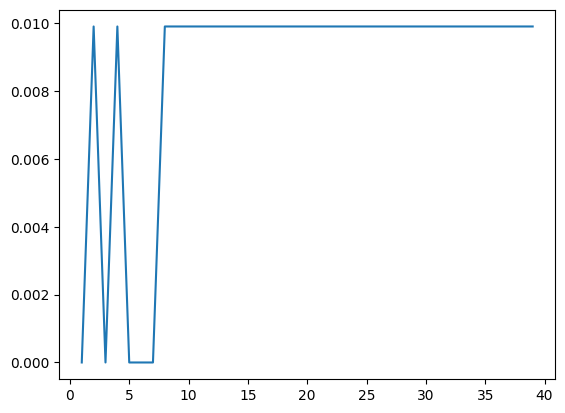

In [59]:
plt.plot(range(1,40), test_error, label ='Test Error')
plt.show()